In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Loading both datasets
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print("matches shape:", matches.shape)
print("deliveries shape:", deliveries.shape)

matches shape: (756, 18)
deliveries shape: (179078, 21)


In [3]:
matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
matches.describe()

,id,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,0.025132,13.283069,3.350529
std,3464.478148,0.156630,23.471144,3.387963
min,1.000000,0.000000,0.000000,0.000000
25%,189.750000,0.000000,0.000000,0.000000
50%,378.500000,0.000000,0.000000,4.000000
75%,567.250000,0.000000,19.000000,6.000000
max,11415.000000,1.000000,146.000000,10.000000


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          179078 non-null  int64 
 1   inning            179078 non-null  int64 
 2   batting_team      179078 non-null  object
 3   bowling_team      179078 non-null  object
 4   over              179078 non-null  int64 
 5   ball              179078 non-null  int64 
 6   batsman           179078 non-null  object
 7   non_striker       179078 non-null  object
 8   bowler            179078 non-null  object
 9   is_super_over     179078 non-null  int64 
 10  wide_runs         179078 non-null  int64 
 11  bye_runs          179078 non-null  int64 
 12  legbye_runs       179078 non-null  int64 
 13  noball_runs       179078 non-null  int64 
 14  penalty_runs      179078 non-null  int64 
 15  batsman_runs      179078 non-null  int64 
 16  extra_runs        179078 non-null  int

In [8]:
#Checking most runs 
total_runs = deliveries.groupby('batsman')['batsman_runs'].sum()

batting_first = deliveries[deliveries['inning'] ==1]
batting_first_runs = batting_first.groupby('batsman')['batsman_runs'].sum()
 
chasing = deliveries[deliveries['inning'] == 2]
chasing_runs = chasing.groupby('batsman')['batsman_runs'].sum()
batsman_complete = pd.DataFrame({
    'total_runs': total_runs,
    'batting_first': batting_first_runs,
    'chasing': chasing_runs
}).dropna()

top_10_complete = batsman_complete.sort_values('total_runs', ascending=False).head(10)
print(top_10_complete)

                total_runs  batting_first  chasing
batsman                                           
V Kohli               5434         2876.0   2553.0
SK Raina              5415         3108.0   2299.0
RG Sharma             4914         2837.0   2077.0
DA Warner             4741         2571.0   2170.0
S Dhawan              4632         2690.0   1942.0
CH Gayle              4560         2632.0   1903.0
MS Dhoni              4477         2632.0   1845.0
RV Uthappa            4446         1822.0   2622.0
AB de Villiers        4428         2616.0   1799.0
G Gambhir             4223         1759.0   2464.0


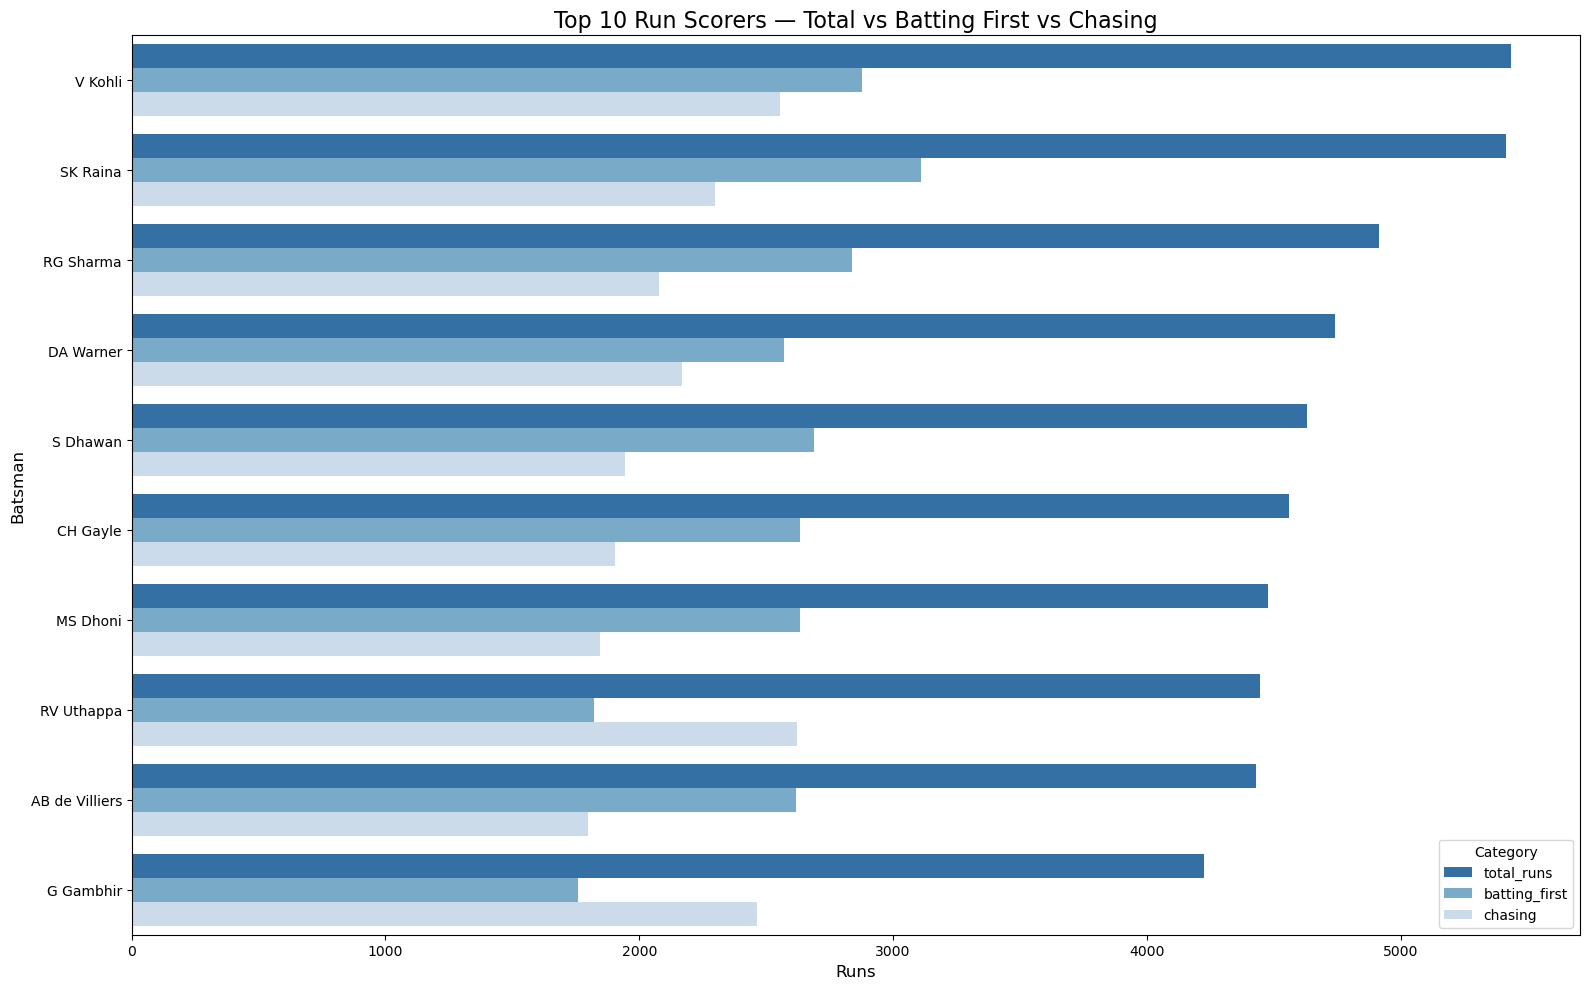

In [9]:
top_10_melted = top_10_complete.reset_index().melt(
    id_vars='batsman',
    value_vars=['total_runs', 'batting_first', 'chasing'],
    var_name='category',
    value_name='runs'
)

plt.figure(figsize=(16,10))
sns.barplot(data=top_10_melted,
            x='runs',
            y='batsman',
            hue='category',
            palette='Blues_r')

plt.title('Top 10 Run Scorers — Total vs Batting First vs Chasing', fontsize=16)
plt.xlabel('Runs', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [10]:
chasing_vs_batting = pd.DataFrame({
    'batting_first': batting_first_runs,
    'chasing': chasing_runs
}).dropna()

chasing_vs_batting = chasing_vs_batting[chasing_vs_batting['batting_first'] > 500]
chasing_vs_batting['difference'] = chasing_vs_batting['chasing'] - chasing_vs_batting['batting_first']

top_chasers = chasing_vs_batting.sort_values('difference', ascending=False).head(10)
print(top_chasers)

                  batting_first  chasing  difference
batsman                                             
RV Uthappa               1822.0   2622.0       800.0
G Gambhir                1759.0   2464.0       705.0
JH Kallis                 934.0   1493.0       559.0
YK Pathan                1340.0   1883.0       543.0
JC Buttler                518.0    912.0       394.0
KL Rahul                  838.0   1175.0       337.0
SR Watson                1636.0   1972.0       336.0
DPMD Jayawardene          760.0   1042.0       282.0
DA Miller                 840.0   1035.0       195.0
SV Samson                1020.0   1215.0       195.0


In [11]:
top_batting_first = chasing_vs_batting.sort_values('difference', ascending=True).head(10).copy()
top_batting_first['difference'] = top_batting_first['difference'].abs()
print(top_batting_first)

                batting_first  chasing  difference
batsman                                           
AB de Villiers         2616.0   1799.0       817.0
SK Raina               3108.0   2299.0       809.0
MS Dhoni               2632.0   1845.0       787.0
RG Sharma              2837.0   2077.0       760.0
S Dhawan               2690.0   1942.0       748.0
CH Gayle               2632.0   1903.0       729.0
MEK Hussey             1313.0    664.0       649.0
JP Duminy              1344.0    697.0       647.0
WP Saha                1156.0    624.0       532.0
BB McCullum            1692.0   1199.0       493.0


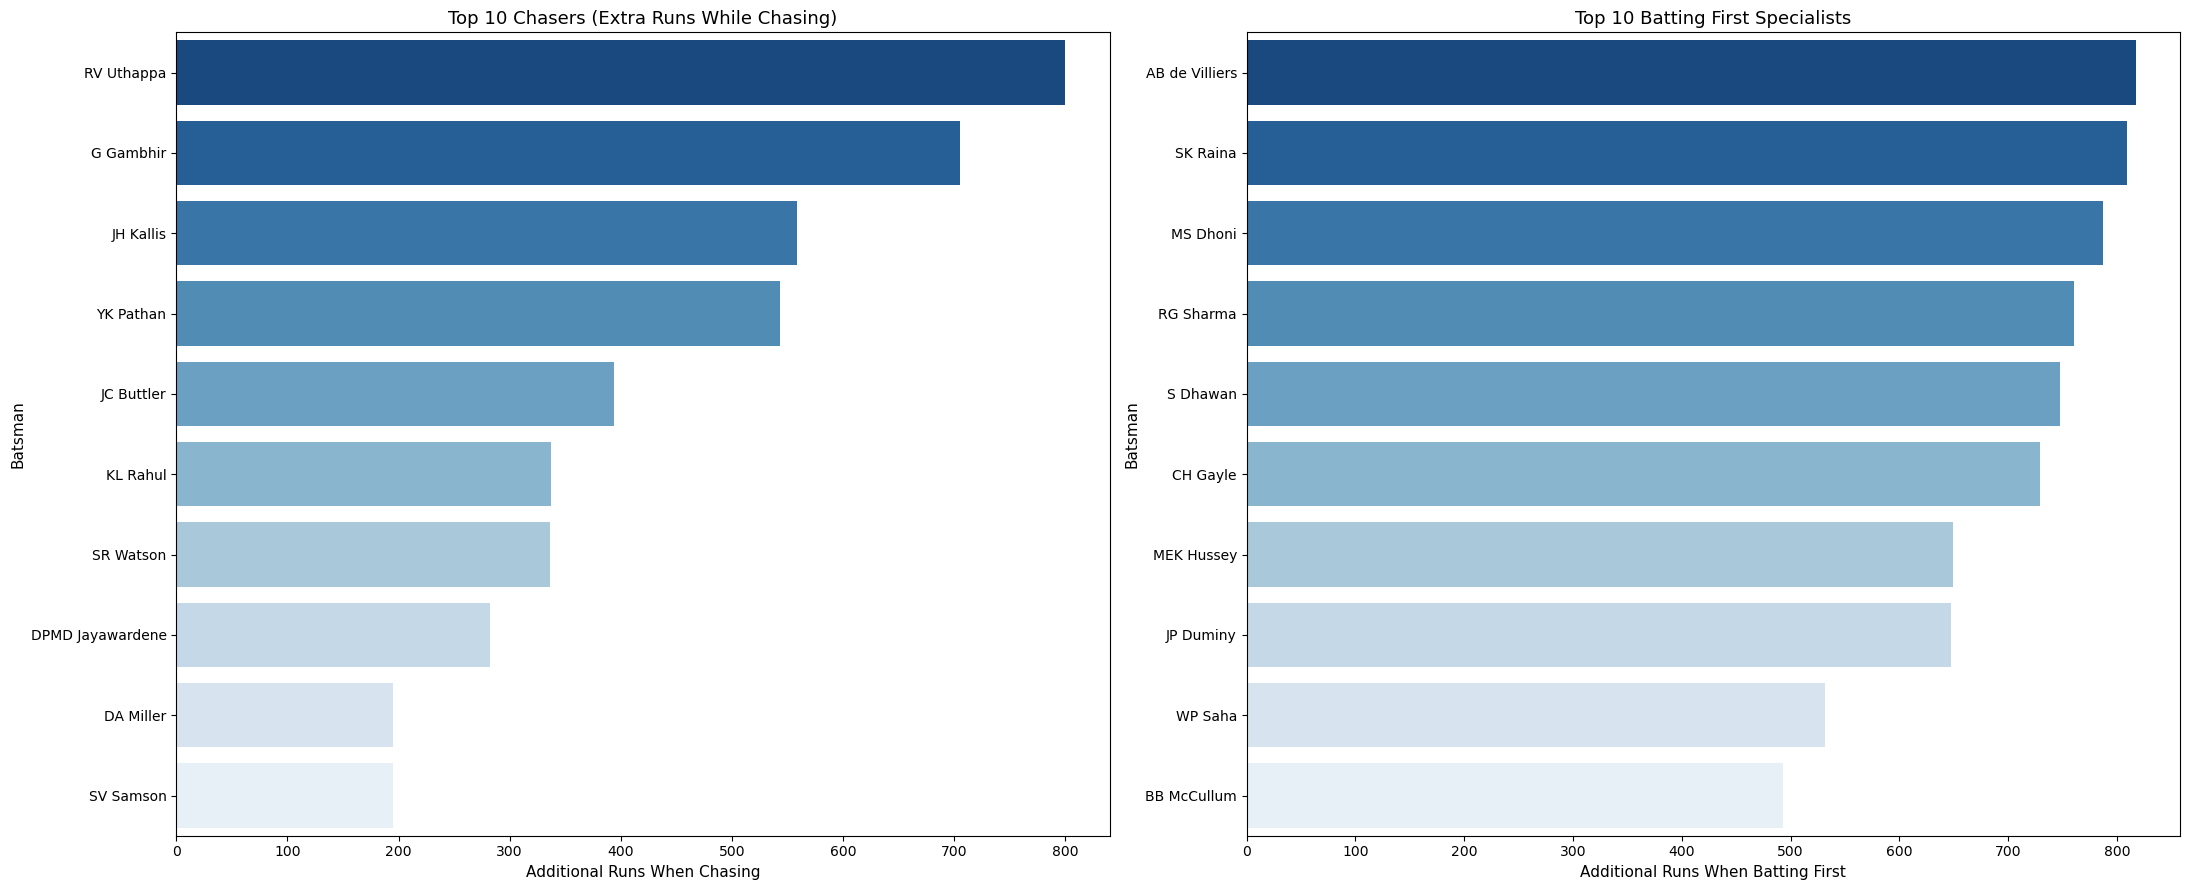

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(22,9))
sns.barplot(x=top_chasers['difference'],
            y=top_chasers.index,
            palette='Blues_r',
            hue=top_chasers.index,
            legend=False,
            ax=axes[0])
axes[0].set_title('Top 10 Chasers (Extra Runs While Chasing)', fontsize=13)
axes[0].set_xlabel('Additional Runs When Chasing', fontsize=11)
axes[0].set_ylabel('Batsman', fontsize=11)

sns.barplot(x=top_batting_first['difference'],
            y=top_batting_first.index,
            palette='Blues_r',
            hue=top_batting_first.index,
            legend=False,
            ax=axes[1])
axes[1].set_title('Top 10 Batting First Specialists', fontsize=13)
axes[1].set_xlabel('Additional Runs When Batting First', fontsize=11)
axes[1].set_ylabel('Batsman', fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
deliveries['dismissal_kind'].value_counts()

dismissal_kind
caught                   5348
bowled                   1581
run out                   852
lbw                       540
stumped                   278
caught and bowled         211
retired hurt               12
hit wicket                 10
obstructing the field       2
Name: count, dtype: int64

In [16]:
bowler_wickets = ['caught', 'bowled', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
wickets_df = deliveries[deliveries['dismissal_kind'].isin(bowler_wickets)]

total_wickets = wickets_df.groupby('bowler')['match_id'].count()

bowling_first = deliveries[deliveries['inning'] == 1]
bowling_first_wickets = bowling_first[bowling_first['dismissal_kind'].isin(bowler_wickets)].groupby('bowler')['match_id'].count()

# Wickets while defending (inning 2)
defending = deliveries[deliveries['inning'] == 2]
defending_wickets = defending[defending['dismissal_kind'].isin(bowler_wickets)].groupby('bowler')['match_id'].count()

# Combine into one DataFrame
bowler_complete = pd.DataFrame({
    'total_wickets': total_wickets,
    'bowling_first': bowling_first_wickets,
    'defending': defending_wickets
}).dropna()

# Top 10 by total wickets
top_10_bowlers_complete = bowler_complete.sort_values('total_wickets', ascending=False).head(10)
print(top_10_bowlers_complete)

                 total_wickets  bowling_first  defending
bowler                                                  
SL Malinga                 170           84.0       86.0
A Mishra                   156           60.0       96.0
Harbhajan Singh            150           58.0       92.0
PP Chawla                  149           78.0       71.0
DJ Bravo                   147           79.0       68.0
B Kumar                    133           71.0       62.0
R Ashwin                   125           51.0       74.0
SP Narine                  122           68.0       54.0
UT Yadav                   119           83.0       36.0
RA Jadeja                  108           57.0       51.0


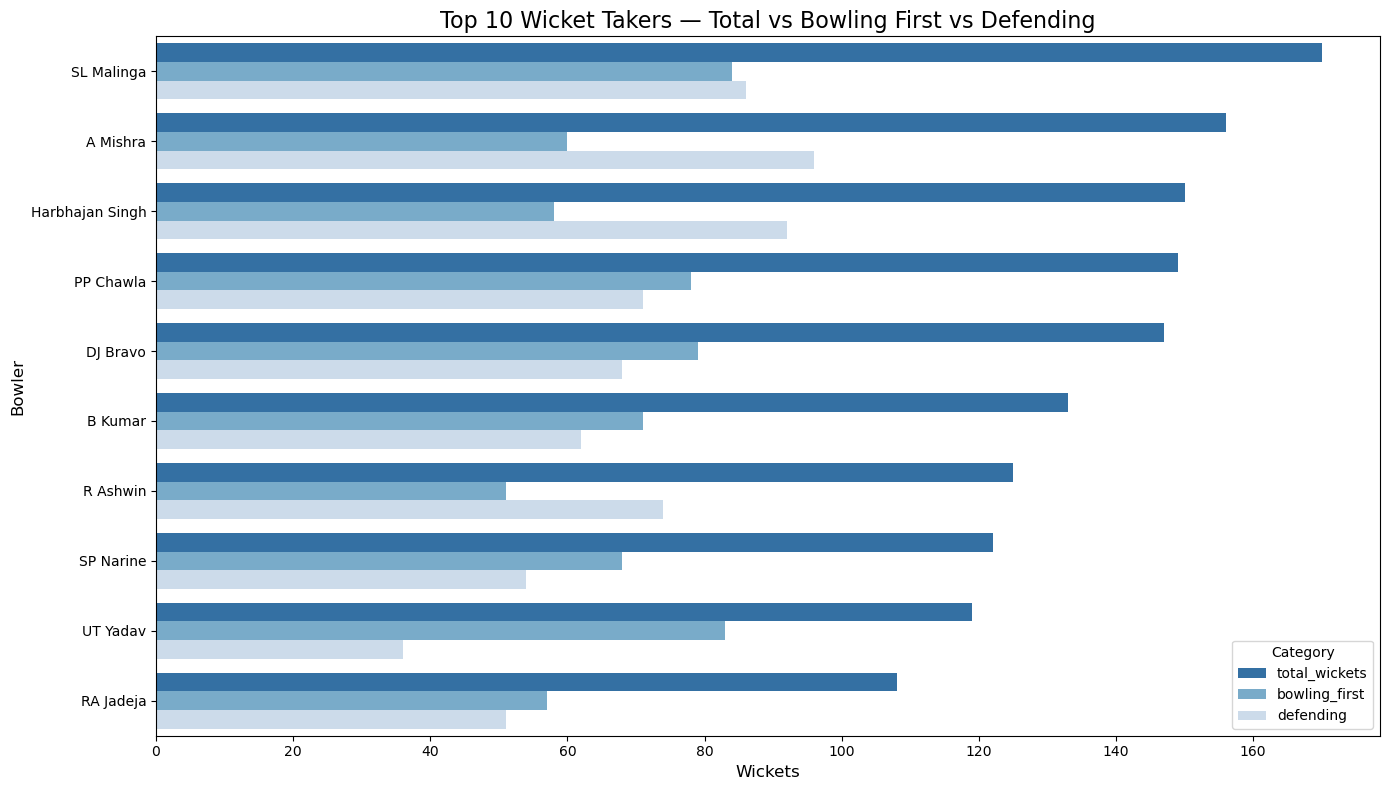

In [17]:
top_10_bowlers_melted = top_10_bowlers_complete.reset_index().melt(
    id_vars='bowler',
    value_vars=['total_wickets', 'bowling_first', 'defending'],
    var_name='category',
    value_name='wickets'
)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_10_bowlers_melted,
            x='wickets',
            y='bowler',
            hue='category',
            palette='Blues_r')

plt.title('Top 10 Wicket Takers — Total vs Bowling First vs Defending', fontsize=16)
plt.xlabel('Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [15]:
team_wins=matches['winner'].value_counts()
team_wins.head(25)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [16]:
all_teams_per_match = pd.concat([matches['team1'], matches['team2']])
matches_played = all_teams_per_match.value_counts()
matches_played.head(25)

Mumbai Indians                 187
Royal Challengers Bangalore    180
Kolkata Knight Riders          178
Kings XI Punjab                176
Chennai Super Kings            164
Delhi Daredevils               161
Rajasthan Royals               147
Sunrisers Hyderabad            108
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          16
Delhi Capitals                  16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [17]:
win_percentage = (team_wins / matches_played * 100).sort_values(ascending=False)
win_percentage.head(25)

Delhi Capitals                 62.500000
Rising Pune Supergiant         62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64

In [18]:
matches[matches['team1'].str.contains('Rising Pune', case=False)]['team1'].unique()

array(['Rising Pune Supergiant', 'Rising Pune Supergiants'], dtype=object)

In [19]:
matches[matches['team2'].str.contains('Rising Pune', case=False)]['team2'].unique()
matches[matches['winner'].str.contains('Rising Pune', case=False, na=False)]['winner'].unique()

array(['Rising Pune Supergiant', 'Rising Pune Supergiants'], dtype=object)

In [20]:
# Fix the inconsistent team name in all three relevant columns
name_fix = {'Rising Pune Supergiants': 'Rising Pune Supergiant'}

matches['team1'] = matches['team1'].replace(name_fix)
matches['team2'] = matches['team2'].replace(name_fix)
matches['winner'] = matches['winner'].replace(name_fix)

In [21]:
team_wins=matches['winner'].value_counts()
team_wins.head(25)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [22]:
all_teams_per_match = pd.concat([matches['team1'], matches['team2']])
matches_played = all_teams_per_match.value_counts()
matches_played.head(25)

Mumbai Indians                 187
Royal Challengers Bangalore    180
Kolkata Knight Riders          178
Kings XI Punjab                176
Chennai Super Kings            164
Delhi Daredevils               161
Rajasthan Royals               147
Sunrisers Hyderabad            108
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          30
Delhi Capitals                  16
Kochi Tuskers Kerala            14
Name: count, dtype: int64

In [23]:
win_percentage = (team_wins / matches_played * 100).sort_values(ascending=False)
win_percentage.head(25)

Delhi Capitals                 62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Rising Pune Supergiant         50.000000
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Pune Warriors                  26.086957
Name: count, dtype: float64

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20696\3762411905.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_percentage.index,


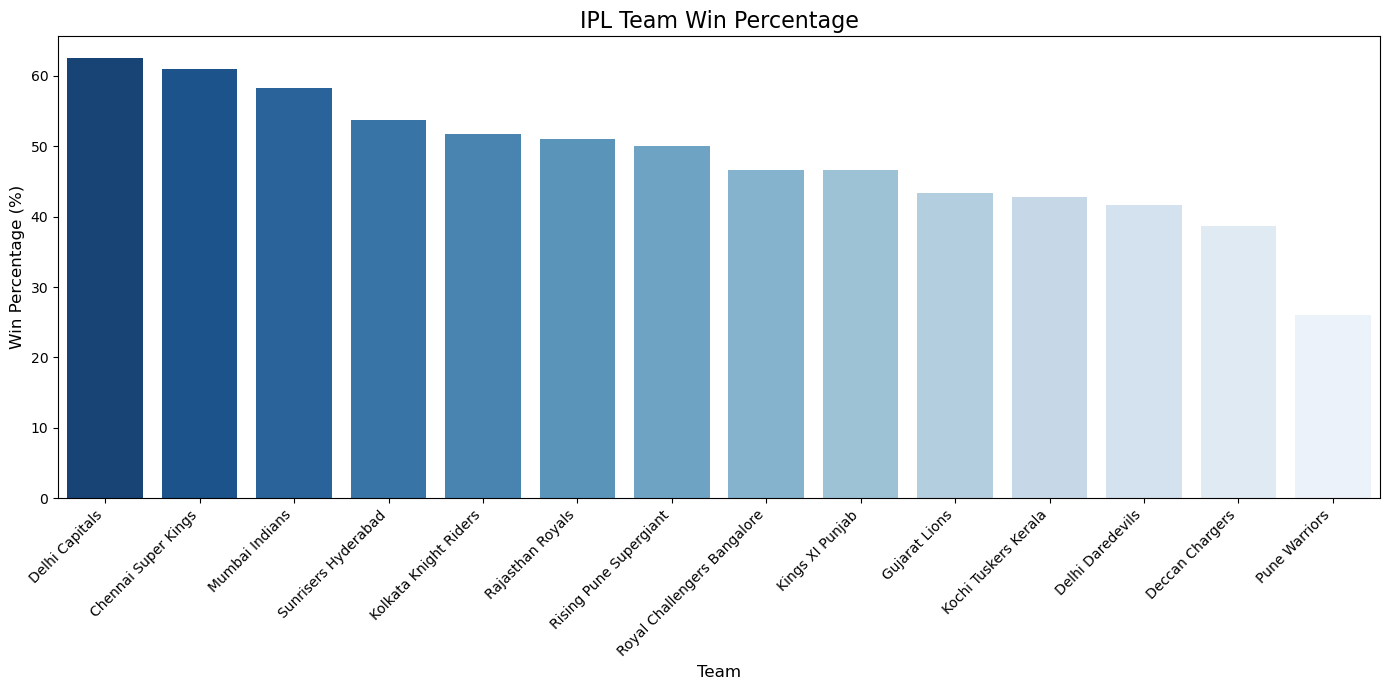

In [24]:
plt.figure(figsize=(14, 7))
sns.barplot(x=win_percentage.index,
            y=win_percentage.values,
            palette='Blues_r',
            legend=False)

plt.title('IPL Team Win Percentage', fontsize=16)
plt.xlabel('Team', fontsize=12)
plt.ylabel('Win Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
(matches['toss_winner'] == matches['winner']).sum()  

np.int64(390)

In [26]:
toss_win_match_win=(matches['toss_winner']==matches['winner']).sum()/len(matches) * 100
print(f"Toss winner also won the match: {toss_win_match_win:.2f}%")

Toss winner also won the match: 51.59%


In [27]:
toss_winner_won = matches[matches['toss_winner'] == matches['winner']]

toss_winner_won['toss_decision'].value_counts()

toss_decision
field    256
bat      134
Name: count, dtype: int64

In [28]:
matches['toss_decision'].value_counts()

toss_decision
field    463
bat      293
Name: count, dtype: int64

In [29]:
toss_decision_counts = matches['toss_decision'].value_counts()
toss_winner_decision = toss_winner_won['toss_decision'].value_counts()

decision_win_pct = (toss_winner_decision / toss_decision_counts * 100).round(2)
print(decision_win_pct)

toss_decision
field    55.29
bat      45.73
Name: count, dtype: float64


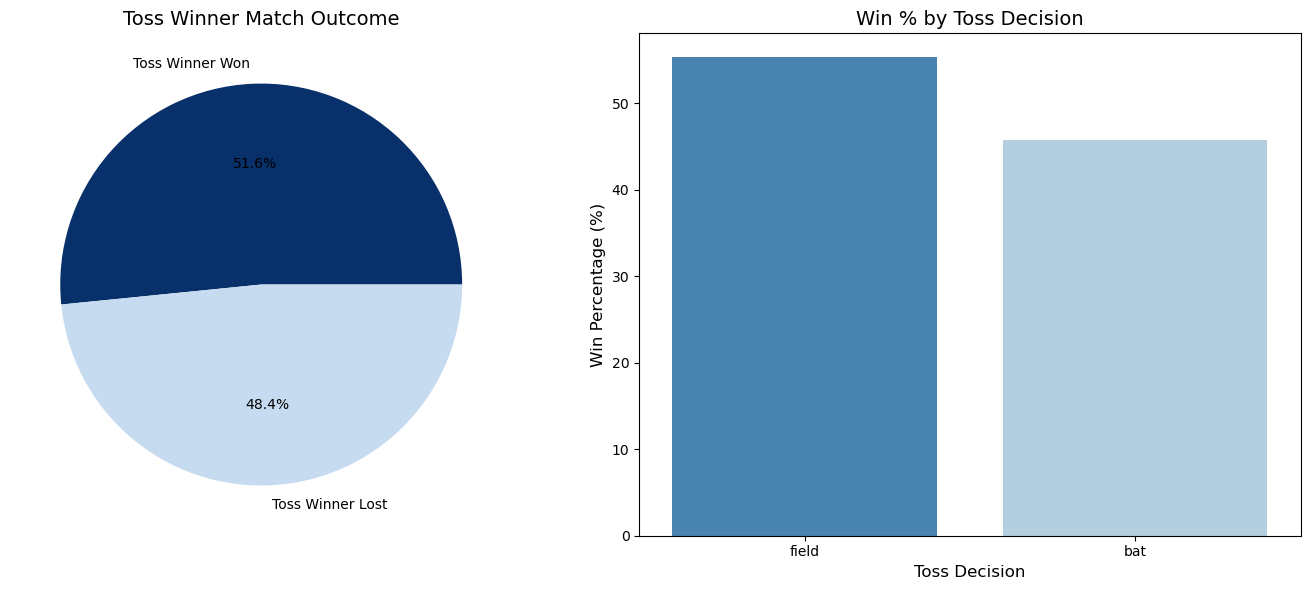

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 - Pie chart on the left
axes[0].pie([toss_win_match_win, 100 - toss_win_match_win],
            labels=['Toss Winner Won', 'Toss Winner Lost'],
            autopct='%1.1f%%',
            colors=['#08306b', '#c6dbef'])
axes[0].set_title('Toss Winner Match Outcome', fontsize=14)

# Chart 2 - Bar chart on the right
sns.barplot(x=decision_win_pct.index,
            y=decision_win_pct.values,
            palette='Blues_r',
            hue=decision_win_pct.index,
            legend=False,
            ax=axes[1])
axes[1].set_title('Win % by Toss Decision', fontsize=14)
axes[1].set_xlabel('Toss Decision', fontsize=12)
axes[1].set_ylabel('Win Percentage (%)', fontsize=12)

plt.tight_layout()
plt.show()

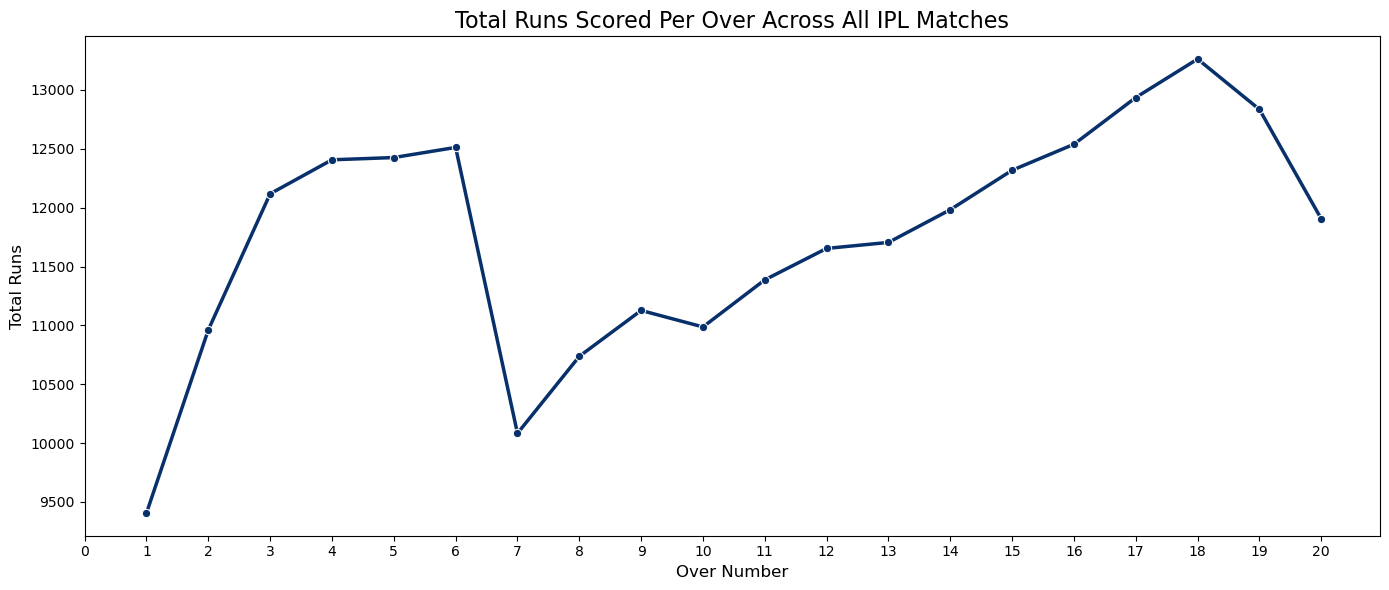

In [31]:
runs_per_over = deliveries.groupby('over')['total_runs'].sum()

plt.figure(figsize=(14, 6))

sns.lineplot(x=runs_per_over.index,
             y=runs_per_over.values,
             color='#08306b',
             linewidth=2.5,
             marker='o',
             markersize=6)

plt.title('Total Runs Scored Per Over Across All IPL Matches', fontsize=16)
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Total Runs', fontsize=12)
plt.xticks(range(0, 21))

plt.tight_layout()
plt.show()